<a href="https://colab.research.google.com/github/ALAAMEKAWY56/deep-learning-mnist-classifier/blob/main/deep_learning_mnist_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import libraries

In [41]:
import tensorflow as tf

## Load MNIST dataset

In [2]:
(x_train , y_train),(x_test , y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

## Data preprocessing

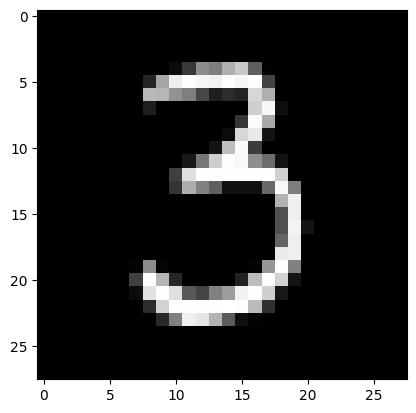

In [5]:
import matplotlib.pyplot as plt
def plot_digit(img) :
  img = img.reshape(28 , 28)
  plt.imshow(img , cmap = 'gray')
  plt.show()
plot_digit(x_train[50 , : , :])

In [6]:
x_train_reshaped = x_train.reshape(60000 , -1)

In [7]:
x_train_reshaped.shape

(60000, 784)

In [8]:
img = x_train_reshaped[50 , :]

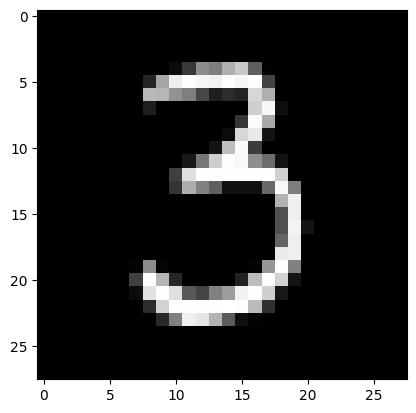

In [9]:
plot_digit(img)

In [10]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)
y_train_5

array([ True, False, False, ...,  True, False, False])

In [11]:
y_train_5 = y_train_5.reshape(-1 , 1)

In [12]:
y_train_5.shape

(60000, 1)

In [13]:
y_test_5 = y_test_5.reshape(-1 , 1)

In [14]:
y_test_5

array([[False],
       [False],
       [False],
       ...,
       [False],
       [ True],
       [False]])

In [15]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from os import name

 ## Build Neural Network model

In [16]:
model = Sequential([Input(shape = (28,28) , name = 'input') ,
                    Flatten(),
                    Dense(784 , activation = 'relu' , name = 'hidden_1'),
                    Dense(784 , activation = 'relu' , name = 'hidden_2'),
                    Dropout(0.1),
                    Dense(1 , activation = 'sigmoid' , name = 'output'),])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,231,665 (4.70 MB)

 Trainable params: 1,231,665 (4.70 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.optimizers import SGD

In [19]:
optimizer = SGD(learning_rate = 0.001)
model.compile(optimizer= optimizer , loss = 'binary_crossentropy'
, metrics = ['accuracy' , 'f1_score'])

In [20]:
from IPython.core import history

## Train the model (Binary Classification)


In [21]:
history = model.fit(x_train,y_train_5,
                    batch_size = 32,
                    validation_split= 0.1,
                    shuffle = True ,
                    epochs = 50)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9640 - f1_score: 0.6417 - loss: 2.4679 - val_accuracy: 0.9833 - val_f1_score: 0.4518 - val_loss: 0.1150
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9914 - f1_score: 0.6067 - loss: 0.0475 - val_accuracy: 0.9910 - val_f1_score: 0.7212 - val_loss: 0.0846
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9968 - f1_score: 0.6169 - loss: 0.0125 - val_accuracy: 0.9898 - val_f1_score: 0.5120 - val_loss: 0.0741
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9974 - f1_score: 0.6120 - loss: 0.0108 - val_accuracy: 0.9925 - val_f1_score: 0.6913 - val_loss: 0.0782
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9988 - f1_score: 0.6256 - loss: 0.0042 - val_accuracy: 0.9928 - val_f1_score: 0.6679 - val_loss: 0.0682
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9990 - f1_score: 0.6248 - loss: 0.0029 - val_accuracy: 0.9935 - val_f1_s

In [22]:
def plot_loss_acc(history , model_name = 'model_1'):
  plt.title(f'loss{model_name}')
  plt.plot(history.history['loss'] , c = 'r',
           label = 'Train_loss')
  plt.plot(history.history['val_loss'] ,c ='g',
           label = 'valid_loss')
  plt.legend()
  plt.show()
  plt.title(f'accuracy{model_name}')
  plt.plot(history.history['accuracy'] , c ='r',
           label = 'Train_accuracy')
  plt.plot(history.history['val_accuracy'] , c ='g',
           label = 'valid_accuracy')
  plt.legend()
  plt.show()

## Evaluate the model

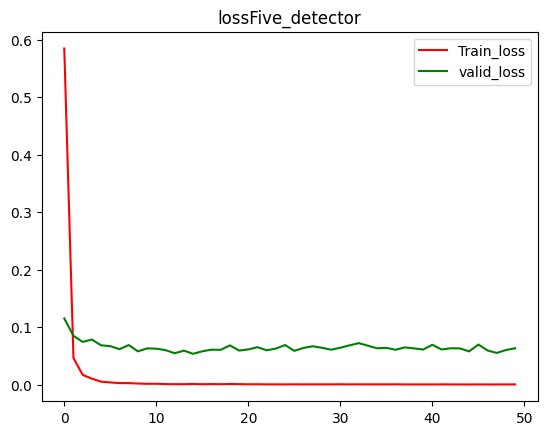

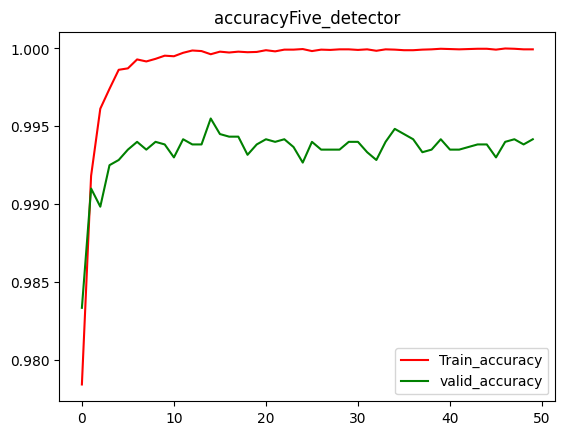

In [23]:
plot_loss_acc(history , model_name = 'Five_detector')

In [24]:
multiclass_model = Sequential([
    Input(shape = (28 , 28) , name = 'input'),
    Flatten(),
    Dense(300 , activation = 'relu' , name = 'hidden_1'),
    Dense(300 , activation = 'relu' , name = 'hidden_2'),
    Dense(10 , activation= 'softmax' , name = 'output')
])
model_name = 'multiclass_model'

In [25]:
multiclass_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,810 (1.25 MB)

 Trainable params: 328,810 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

##Train the model (Multi Class Classification)

In [26]:
from tensorflow.keras.optimizers import Adam

In [27]:
optimizer = Adam(learning_rate = 0.001)
multiclass_model.compile(optimizer= optimizer ,
              loss = 'sparse_categorical_crossentropy' ,
                         metrics = ['accuracy'])

In [28]:
history = multiclass_model.fit(x_train,y_train,
                    batch_size = 32,
                    validation_split= 0.1,
                    shuffle = True ,
                    epochs = 50)

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8470 - loss: 4.5860 - val_accuracy: 0.9375 - val_loss: 0.2810
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9439 - loss: 0.2456 - val_accuracy: 0.9532 - val_loss: 0.1810
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9549 - loss: 0.1650 - val_accuracy: 0.9657 - val_loss: 0.1508
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9581 - loss: 0.1637 - val_accuracy: 0.9678 - val_loss: 0.1261
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9629 - loss: 0.1384 - val_accuracy: 0.9612 - val_loss: 0.1513
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9635 - loss: 0.1349 - val_accuracy: 0.9653 - val_loss: 0.1475
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9680 - loss: 0.1157 - val_accuracy: 0.9673 - val_loss: 0.1490
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9715 - loss: 0.1101 - 

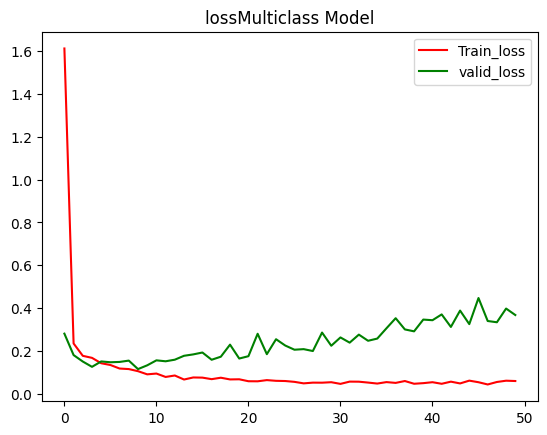

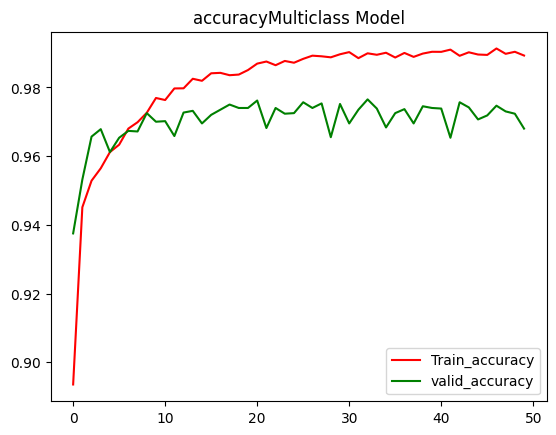

In [29]:
plot_loss_acc(history , model_name = 'Multiclass Model')

In [30]:
from tensorflow.keras.models import Model

In [31]:
model_name = 'Multiclass_Funcational_Model'

In [33]:
input_ = Input(shape = (28 , 28))
hidden = Flatten()(input_)
hidden = Dense(784 , activation = 'relu')(hidden)
hidden = Dense(784 , activation = 'relu')(hidden)
hidden = Dropout(0.1)(hidden)
output = Dense(10 , activation = 'softmax')(hidden)

In [35]:
multiclass_Functional_model = Model(inputs = [input_] , outputs = [output] )
multiclass_Functional_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,238,730 (4.73 MB)

 Trainable params: 1,238,730 (4.73 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
optimizer = Adam(learning_rate = 0.001)

In [37]:
multiclass_Functional_model.compile(optimizer = optimizer ,
                                    loss = 'sparse_categorical_crossentropy' ,
                                    metrics = ['accuracy'])

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

In [40]:
es_callback = EarlyStopping(monitor = 'val_loss' , min_delta = 0.001 , patience = 5)
history = multiclass_Functional_model.fit(x_train , y_train,
                                          validation_split = 0.1 ,
                                          shuffle = True,
                                          epochs = 50,
                                          callbacks = [es_callback])

Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9693 - loss: 0.1303 - val_accuracy: 0.9718 - val_loss: 0.1828
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9736 - loss: 0.1204 - val_accuracy: 0.9725 - val_loss: 0.1612
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9728 - loss: 0.1136 - val_accuracy: 0.9712 - val_loss: 0.2129
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9751 - loss: 0.1073 - val_accuracy: 0.9652 - val_loss: 0.2476
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9736 - loss: 0.1259 - val_accuracy: 0.9678 - val_loss: 0.2178
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9774 - loss: 0.1070 - val_accuracy: 0.9715 - val_loss: 0.2569
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9766 - loss: 0.1105 - val_accuracy: 0.9733 - val_loss: 0.1983
